<a href="https://colab.research.google.com/github/VaibhavK010/Handwritten_Digit_Recognition_ANN/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [2]:
df = pd.read_csv("mnist_train.csv")

In [3]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
X = df.drop("label", axis=1)
y = df["label"]

print("Input Features:", X.columns)
print("Target Variable:", y.name)

Input Features: Index(['1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9', '1x10',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=784)
Target Variable: label


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4594, 785)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4594 entries, 0 to 4593
Columns: 785 entries, label to 28x28
dtypes: float64(778), int64(7)
memory usage: 27.5 MB


In [7]:
df.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,4594.000000,4594.0,4594.0,4594.0,4594.0,4594.0,4594.0,4593.0,4593.0,4593.0,...,4593.000000,4593.000000,4593.000000,4593.000000,4593.000000,4593.0,4593.0,4593.0,4593.0,4593.0
mean,4.470832,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.155889,0.073590,0.033529,0.055084,0.039843,0.0,0.0,0.0,0.0,0.0
std,2.869109,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.814964,2.946131,2.116224,2.916337,1.993550,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,223.000000,156.000000,143.000000,187.000000,119.000000,0.0,0.0,0.0,0.0,0.0


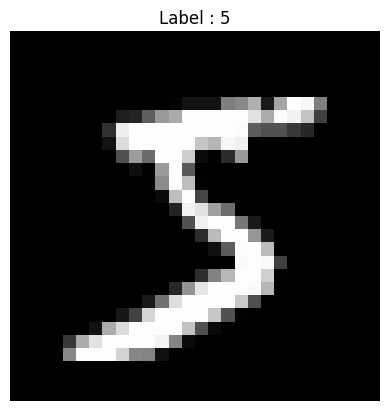

In [8]:
image = X.iloc[0].values.reshape(28,28)

plt.imshow(image, cmap="gray")
plt.title(f"Label : {y.iloc[0]}")
plt.axis("off")
plt.show()

In [9]:
print(df.isnull().sum())

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    1
28x25    1
28x26    1
28x27    1
28x28    1
Length: 785, dtype: int64


In [10]:
X = df.drop("label", axis=1)
y = df["label"]

In [11]:
X = X / 255.0

In [12]:
y = to_categorical(y, num_classes=10)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7439 - loss: 0.9283 - val_accuracy: 0.8667 - val_loss: 0.4262
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9129 - loss: 0.3201 - val_accuracy: 0.8803 - val_loss: 0.3960
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9412 - loss: 0.2199 - val_accuracy: 0.9116 - val_loss: 0.2959
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9520 - loss: 0.1689 - val_accuracy: 0.9197 - val_loss: 0.2898
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9636 - loss: 0.1340 - val_accuracy: 0.9197 - val_loss: 0.2848
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9738 - loss: 0.0940 - val_accuracy: 0.9279 - val_loss: 0.2612
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9840 - loss: 0.0706 - val_accuracy: 0.9320 - val_loss: 0.2699
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9895 - loss: 0.0529 - val_accuracy: 0.9374 - v

In [17]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [18]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9227 - loss: nan
Test Accuracy: 0.9227421283721924


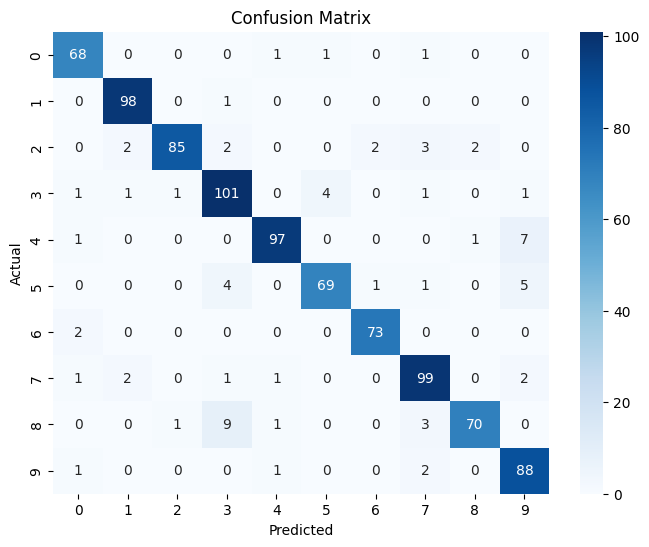

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        71
           1       0.95      0.99      0.97        99
           2       0.98      0.89      0.93        96
           3       0.86      0.92      0.89       110
           4       0.96      0.92      0.94       106
           5       0.93      0.86      0.90        80
           6       0.96      0.97      0.97        75
           7       0.90      0.93      0.92       106
           8       0.96      0.83      0.89        84
           9       0.85      0.96      0.90        92

    accuracy                           0.92       919
   macro avg       0.93      0.92      0.92       919
weighted avg       0.93      0.92      0.92       919



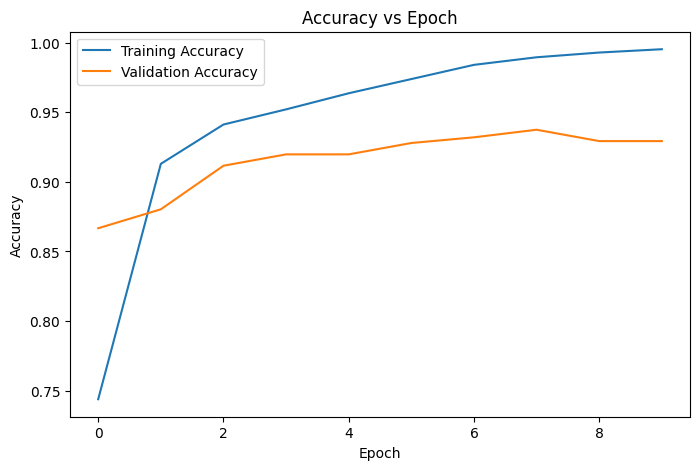

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.show()

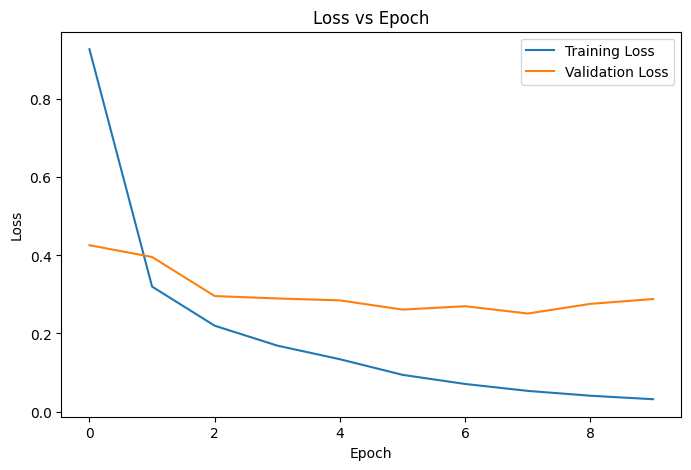

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

plt.show()